# MSBA 265 – Foundational Module 1: Exploratory Data Analysis & Visual Outlier Audits

**Author:** Visiting Instructor Shyla Solis  
**Course:** MSBA 265 – Business Analytics Topics  
**Dataset:** French Motor Third Party Liability Claims (OpenML ID: 41214)

---

### Business Problem Overview

In property and casualty insurance, policy pricing depends on understanding risk exposure, driver age, and population density. Before building predictive loss models or business strategy dashboards, we must inspect raw feature data types, construct a domain-specific Business Data Dictionary, plot feature distributions, evaluate univariate skewness, and visually diagnose extreme outliers.

In [38]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual styling for clean presentation graphics
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 10
pd.set_option('display.max_columns', 20)

# Load dataset
data_path = os.path.join("..", "data", "raw_business_data.csv")
if not os.path.exists(data_path):
    data_path = os.path.join("data", "raw_business_data.csv")

df = pd.read_csv(data_path)
print(f"[+] Loaded Dataset Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")

# Render interactive HTML table head
df.head(10)

[+] Loaded Dataset Shape: 678,013 rows x 12 columns


,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region
0,1.0,1,0.10,'D',5,0,55,50,'B12','Regular',1217,'R82'
1,3.0,1,0.77,'D',5,0,55,50,'B12','Regular',1217,'R82'
2,5.0,1,0.75,'B',6,2,52,50,'B12','Diesel',54,'R22'
3,10.0,1,0.09,'B',7,0,46,50,'B12','Diesel',76,'R72'
4,11.0,1,0.84,'B',7,0,46,50,'B12','Diesel',76,'R72'
5,13.0,1,0.52,'E',6,2,38,50,'B12','Regular',3003,'R31'
6,15.0,1,0.45,'E',6,2,38,50,'B12','Regular',3003,'R31'
7,17.0,1,0.27,'C',7,0,33,68,'B12','Diesel',137,'R91'
8,18.0,1,0.71,'C',7,0,33,68,'B12','Diesel',137,'R91'
9,21.0,1,0.15,'B',7,0,41,50,'B12','Diesel',60,'R52'


### Part 2.1 – Structural Data Types & Summary Statistics

In [39]:
print("==================================================")
print("          1. STRUCTURAL DATA TYPES & NULLS        ")
print("==================================================")
df.info()

print("\n==================================================")
print("          2. SUMMARY STATISTICS (NUMERICAL)       ")
print("==================================================")
df.describe().T

          1. STRUCTURAL DATA TYPES & NULLS        
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 678013 entries, 0 to 678012
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   IDpol       678013 non-null  float64
 1   ClaimNb     678013 non-null  int64  
 2   Exposure    678013 non-null  float64
 3   Area        678013 non-null  object 
 4   VehPower    678013 non-null  int64  
 5   VehAge      678013 non-null  int64  
 6   DrivAge     678013 non-null  int64  
 7   BonusMalus  678013 non-null  int64  
 8   VehBrand    678013 non-null  object 
 9   VehGas      678013 non-null  object 
 10  Density     678013 non-null  int64  
 11  Region      678013 non-null  object 
dtypes: float64(2), int64(6), object(4)
memory usage: 62.1+ MB

          2. SUMMARY STATISTICS (NUMERICAL)       


,count,mean,std,min,25%,50%,75%,max
IDpol,678013.0,2.621857e+06,1.641783e+06,1.000000,1157951.00,2272152.00,4046274.00,6114330.00
ClaimNb,678013.0,5.324677e-02,2.401173e-01,0.000000,0.00,0.00,0.00,16.00
Exposure,678013.0,5.287501e-01,3.644415e-01,0.002732,0.18,0.49,0.99,2.01
VehPower,678013.0,6.454631e+00,2.050906e+00,4.000000,5.00,6.00,7.00,15.00
VehAge,678013.0,7.044265e+00,5.666232e+00,0.000000,2.00,6.00,11.00,100.00
DrivAge,678013.0,4.549912e+01,1.413744e+01,18.000000,34.00,44.00,55.00,100.00
BonusMalus,678013.0,5.976150e+01,1.563666e+01,50.000000,50.00,50.00,64.00,230.00
Density,678013.0,1.792422e+03,3.958647e+03,1.000000,92.00,393.00,1658.00,27000.00


### Part 2.2 – Raw Boundary Audit

The raw boundary audit confirms that the required variables fall within their observed data ranges. DrivAge ranges from 18 to 100 years, confirming that no negative-age records are present. Exposure ranges from approximately 0.0027 to 2.01, with no negative values. BonusMalus ranges from 50 to 230. No obvious sentinel null codes or invalid negative values are observed in these audited variables.

### Part 2.3 – Business Data Dictionary Artifact

In [40]:
business_definitions = {
    "IDpol": ("Policy ID", "Key ID", "Unique policy identification key assigned to contract."),
    "ClaimNb": ("Claim Count", "Count", "Total insurance claims filed during policy coverage period."),
    "Exposure": ("Risk Exposure", "Years (0.0–1.0)", "Fraction of year policy was active (e.g., 0.50 = 6 months coverage)."),
    "Area": ("Area Risk Code", "Ordinal Category", "Geographic risk code of policyholder address (A = rural, F = urban)."),
    "VehPower": ("Engine Power", "Tax HP", "Fiscal power rating category of vehicle engine."),
    "VehAge": ("Vehicle Age", "Years", "Age of the insured vehicle in years."),
    "DrivAge": ("Driver Age", "Years", "Age of the primary insured driver in years."),
    "BonusMalus": ("Claim History Index", "Index Score (50–350)", "Regulatory driver risk score (< 100: safe discount; > 100: claim surcharge)."),
    "VehBrand": ("Brand Class", "Category Code", "Anonymized vehicle manufacturer/brand classification code."),
    "VehGas": ("Fuel Type", "Binary Class", "Engine fuel type used (Diesel vs. Regular/Gasoline)."),
    "Density": ("Population Density", "People / km2", "Population density of policyholder’s municipality."),
    "Region": ("Administrative Region", "Region Code", "French administrative region code corresponding to residency location.")
}

dict_list = []

for col in df.columns:
    label, unit, definition = business_definitions.get(
        col, (col, "N/A", "No business definition provided.")
    )

    dict_list.append({
        "Feature Name": col,
        "Business Label": label,
        "Data Type": str(df[col].dtype),
        "Unit": unit,
        "Null Count": df[col].isnull().sum(),
        "Unique Values": df[col].nunique(),
        "Business Definition": definition
    })

dict_df = pd.DataFrame(dict_list)

display(dict_df)

reports_dir = os.path.join("..", "reports")
os.makedirs(reports_dir, exist_ok=True)

dict_path = os.path.join(reports_dir, "data_dictionary.csv")
dict_df.to_csv(dict_path, index=False)

print(f"\n[+] Successfully exported Business Data Dictionary artifact to: {dict_path}")

,Feature Name,Business Label,Data Type,Unit,Null Count,Unique Values,Business Definition
0,IDpol,Policy ID,float64,Key ID,0,678013,Unique policy identification key assigned to c...
1,ClaimNb,Claim Count,int64,Count,0,11,Total insurance claims filed during policy cov...
2,Exposure,Risk Exposure,float64,Years (0.0–1.0),0,181,"Fraction of year policy was active (e.g., 0.50..."
3,Area,Area Risk Code,object,Ordinal Category,0,6,Geographic risk code of policyholder address (...
4,VehPower,Engine Power,int64,Tax HP,0,12,Fiscal power rating category of vehicle engine.
5,VehAge,Vehicle Age,int64,Years,0,78,Age of the insured vehicle in years.
6,DrivAge,Driver Age,int64,Years,0,83,Age of the primary insured driver in years.
7,BonusMalus,Claim History Index,int64,Index Score (50–350),0,115,Regulatory driver risk score (< 100: safe disc...
8,VehBrand,Brand Class,object,Category Code,0,11,Anonymized vehicle manufacturer/brand classifi...
9,VehGas,Fuel Type,object,Binary Class,0,2,Engine fuel type used (Diesel vs. Regular/Gaso...



[+] Successfully exported Business Data Dictionary artifact to: ../reports/data_dictionary.csv


### Part 2.4 – Business Rationale: Exposure Offset and Density/Area Collinearity

Exposure represents the amount of time an insurance policy is active, so it should be treated as a rate offset rather than as a standard predictor. A policy observed for a longer period naturally has more opportunity to generate claims; therefore, claim frequency should be modeled relative to exposure time. In addition, continuous Density and categorical Area should not both be included in the same linear regression model because they capture overlapping geographic risk information. Including both may introduce redundancy and multicollinearity, which can inflate coefficient variance and reduce model stability and interpretability. Therefore, Density should be retained as the continuous geographic predictor while Area can be excluded.

In [41]:
print("======================================================")
print("           UNIVARIATE SKEWNESS DIAGNOSTICS            ")
print("======================================================")

numeric_df = df.select_dtypes(include=[np.number])
skewness_series = numeric_df.skew().sort_values(ascending=False)

skew_summary = pd.DataFrame({
    "Feature": skewness_series.index,
    "Skewness Coefficient": skewness_series.values,
    "Diagnosis": [
        "Extremely Right-Skewed" if s > 3.0
        else "Moderately Skewed" if abs(s) > 1.0
        else "Unskewed / Symmetric"
        for s in skewness_series.values
    ],
    "Action Required": [
        "Log / Box-Cox Transform" if abs(s) > 1.0
        else "Standard Scaler Sufficient"
        for s in skewness_series.values
    ]
})

display(skew_summary)

           UNIVARIATE SKEWNESS DIAGNOSTICS            


,Feature,Skewness Coefficient,Diagnosis,Action Required
0,ClaimNb,5.599613,Extremely Right-Skewed,Log / Box-Cox Transform
1,Density,4.651421,Extremely Right-Skewed,Log / Box-Cox Transform
2,BonusMalus,1.728934,Moderately Skewed,Log / Box-Cox Transform
3,VehPower,1.171344,Moderately Skewed,Log / Box-Cox Transform
4,VehAge,1.147989,Moderately Skewed,Log / Box-Cox Transform
5,DrivAge,0.435759,Unskewed / Symmetric,Standard Scaler Sufficient
6,IDpol,0.237890,Unskewed / Symmetric,Standard Scaler Sufficient
7,Exposure,0.085318,Unskewed / Symmetric,Standard Scaler Sufficient


In [19]:
print("======================================================")
print("           PEARSON MULTICOLLINEARITY AUDIT            ")
print("======================================================")

corr_matrix = numeric_df.corr().abs()

upper_tri = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_pairs = []

for col in upper_tri.columns:
    high_corr_features = upper_tri.index[
        upper_tri[col] >= 0.85
    ].tolist()

    for feat in high_corr_features:
        val = upper_tri.loc[feat, col]

        high_corr_pairs.append({
            "Feature 1": feat,
            "Feature 2": col,
            "Pearson Correlation (|r|)": round(val, 4),
            "Status": "ACTION REQUIRED: Severe Multicollinearity"
        })

if high_corr_pairs:
    display(pd.DataFrame(high_corr_pairs))
else:
    print("[+] No severe collinear feature pairs (|r| >= 0.85) detected across numerical metrics.")

           PEARSON MULTICOLLINEARITY AUDIT            
[+] No severe collinear feature pairs (|r| >= 0.85) detected across numerical metrics.


## Part 3.1 – Pearson Correlation Heatmap

The Pearson correlation heatmap below summarizes the pairwise linear relationships among the numerical variables in the dataset. It is used to identify potential multicollinearity and to evaluate whether any numerical predictors exhibit strong linear associations that may affect downstream modeling.

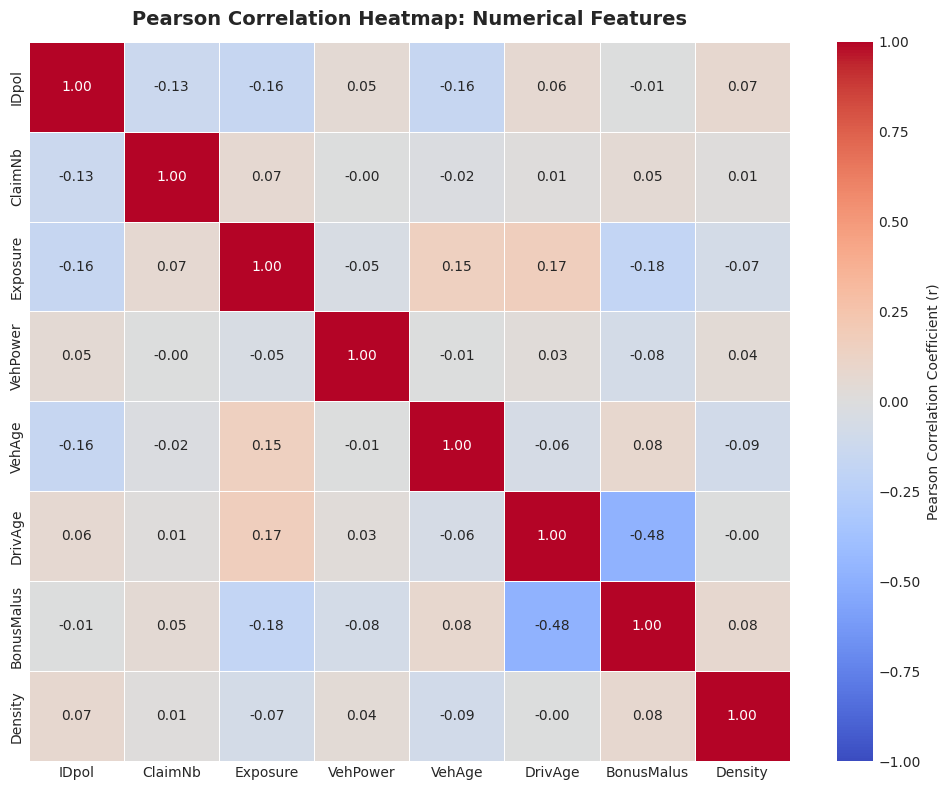

[+] Saved correlation heatmap graphics artifact to: ../reports/figures/correlation_heatmap.png


In [42]:
# Cell 6b: Render Annotated Pearson Correlation Heatmap
plt.figure(figsize=(10, 8))

# Compute Pearson correlation matrix across numerical variables
corr = numeric_df.corr()

# Generate a diverging color map
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1.0,
    vmax=1.0,
    linewidths=0.5,
    cbar_kws={"label": "Pearson Correlation Coefficient (r)"}
)

plt.title(
    "Pearson Correlation Heatmap: Numerical Features",
    fontsize=14,
    fontweight="bold",
    pad=12
)

plt.tight_layout()

heatmap_path = os.path.join(
    "..", "reports", "figures", "correlation_heatmap.png"
)

plt.savefig(heatmap_path, dpi=300)
plt.show()

print(f"[+] Saved correlation heatmap graphics artifact to: {heatmap_path}")

## Part 3.2 – Executive Defense: Override of Automated Transformation for ClaimNb

Although the automated skewness diagnostic identifies `ClaimNb` as extremely right-skewed and recommends a logarithmic or Box-Cox transformation, this recommendation should be overridden. `ClaimNb` is a discrete count variable representing the number of insurance claims, and a large proportion of policyholders have zero claims. Applying a standard logarithmic transformation is mathematically invalid because `log(0) = -∞`. More importantly, zero claims are legitimate business observations rather than missing values or errors, so they must be preserved. Therefore, ClaimNb should remain in its original count form and can be modeled using a Poisson rate framework with log(Exposure) incorporated as an offset.

## Part 4.1 – Distribution Audits: Box Plots and KDE Histograms

The following four distribution diagnostics evaluate Population Density, Driver Age, BonusMalus, and Vehicle Age. The combined figure is exported to `reports/figures/feature_distributions.png`.

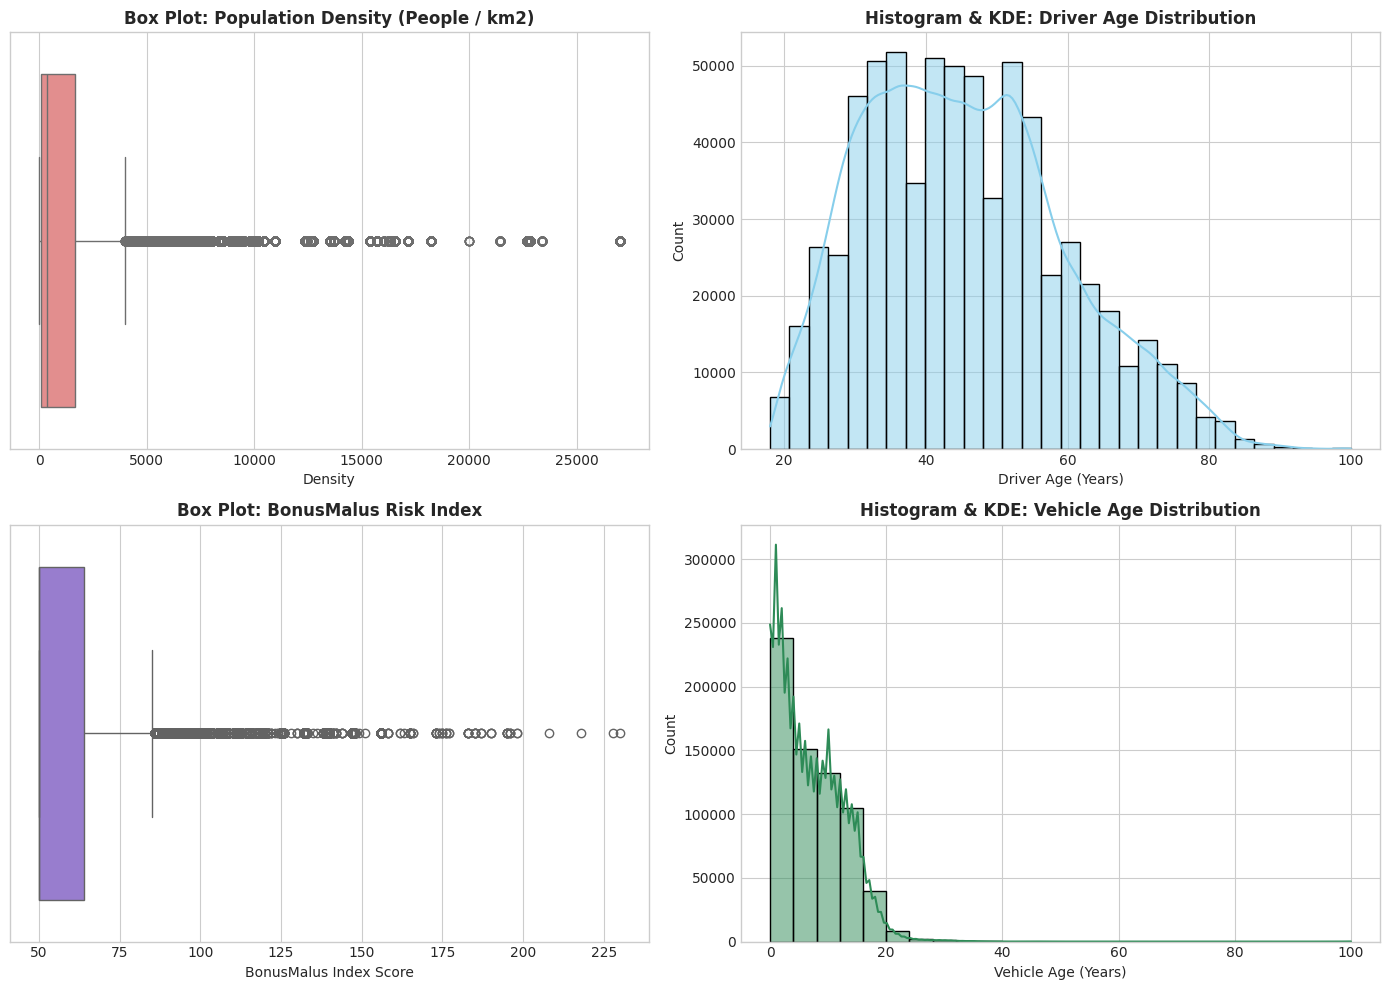

[+] Saved distribution graphics artifact to: ../reports/figures/feature_distributions.png


In [43]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(x=df['Density'], ax=axes[0,0], color='lightcoral')
axes[0,0].set_title('Box Plot: Population Density (People / km2)', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('Density')

sns.histplot(df['DrivAge'], kde=True, ax=axes[0,1], color='skyblue', bins=30)
axes[0,1].set_title('Histogram & KDE: Driver Age Distribution', fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('Driver Age (Years)')

sns.boxplot(x=df['BonusMalus'], ax=axes[1,0], color='mediumpurple')
axes[1,0].set_title('Box Plot: BonusMalus Risk Index', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('BonusMalus Index Score')

sns.histplot(df['VehAge'], kde=True, ax=axes[1,1], color='seagreen', bins=25)
axes[1,1].set_title('Histogram & KDE: Vehicle Age Distribution', fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('Vehicle Age (Years)')

plt.tight_layout()

fig_path = os.path.join("..", "reports", "figures", "feature_distributions.png")
plt.savefig(fig_path, dpi=300)
plt.show()

print(f"[+] Saved distribution graphics artifact to: {fig_path}")

## Part 4.2 – Distribution Audit Interpretations

### 1. Population Density (Density) – Box Plot
- **Distribution Shape:** Density is extremely right-skewed, with most observations concentrated at relatively low population-density levels and a long upper tail representing highly populated metropolitan areas.
- **Key Metrics / Whiskers:** Q1 = 92, median = 393, and Q3 = 1,658 people/km². Using the Tukey 1.5 × IQR rule, the upper fence is approximately 4,007 people/km², while the observed maximum reaches 27,000 people/km².
- **Recommended Analytics Action:** High-density observations should not automatically be deleted because they may represent legitimate metropolitan policyholders rather than data-entry errors. Retain these observations and apply log(1 + Density) before linear regression to reduce the influence of the strong right skew.

### 2. Driver Age (DrivAge) – Histogram & KDE
- **Distribution Shape:** DrivAge is approximately unimodal and relatively symmetric around the middle-age range, with only moderate asymmetry and no severe skewness.
- **Key Metrics / Whiskers:** Q1 = 34 years, median = 44 years, and Q3 = 55 years, with observed ages ranging from 18 to 100 years. These values remain within plausible adult driving ages.
- **Recommended Analytics Action:** No aggressive outlier trimming or logarithmic transformation is necessary. DrivAge can generally be retained in its original scale and standardized if required by the downstream model.

### 3. BonusMalus – Box Plot
- **Distribution Shape:** BonusMalus is right-skewed, with most observations concentrated near the lower end of the index and a smaller number of substantially higher-risk values extending the upper tail.
- **Key Metrics / Whiskers:** Q1 = 50, median = 50, and Q3 = 64. The Tukey upper fence is approximately 85, while the observed maximum reaches 230, producing numerous statistical upper outliers.
- **Recommended Analytics Action:** Retain and scale BonusMalus as a continuous risk variable and create a binary feature Is_Surcharge = BonusMalus > 100 to identify high-risk penalty drivers.

### 4. Vehicle Age (VehAge) – Histogram & KDE
- **Distribution Shape:** VehAge is moderately right-skewed, with most insured vehicles concentrated at younger ages and a long upper tail containing relatively old vehicles.
- **Key Metrics / Whiskers:** Q1 = 2 years, median = 6 years, and Q3 = 11 years, while the maximum recorded vehicle age is 100 years. The observed skewness is approximately 1.15.
- **Recommended Analytics Action:** Retain VehAge and bin it into practical age brackets (0–5 years, 6–10 years, and 11+ years), or apply min-max scaling for downstream modeling.

### 5. Pearson Correlation Heatmap
- **Distribution / Relationship Pattern:** Most pairwise Pearson correlations among the numerical variables are weak, indicating limited linear dependence across the majority of numerical predictors.
- **Key Metrics:** The strongest off-diagonal relationship is between `DrivAge` and `BonusMalus`, with approximately r = -0.48, indicating a moderate negative linear association. The remaining correlations are substantially smaller in absolute magnitude.
- **Recommended Analytics Action:** The heatmap does not indicate severe numerical multicollinearity requiring automatic variable removal. However, the moderate relationship between DrivAge and BonusMalus should be monitored during modeling, while categorical geographic redundancy involving `Area` must be evaluated separately because Area is not represented in the numerical Pearson matrix.

## Outlier Filtering Audit – Density

=== OUTLIER AUDIT REPORT FOR 'Density' ===
Original Record Count: 678,013 records
Tukey IQR Range [-2257.00, 4007.00]: Excludes 77,566 records
Z-Score Threshold (|Z| <= 3.0): Excludes 15,209 records


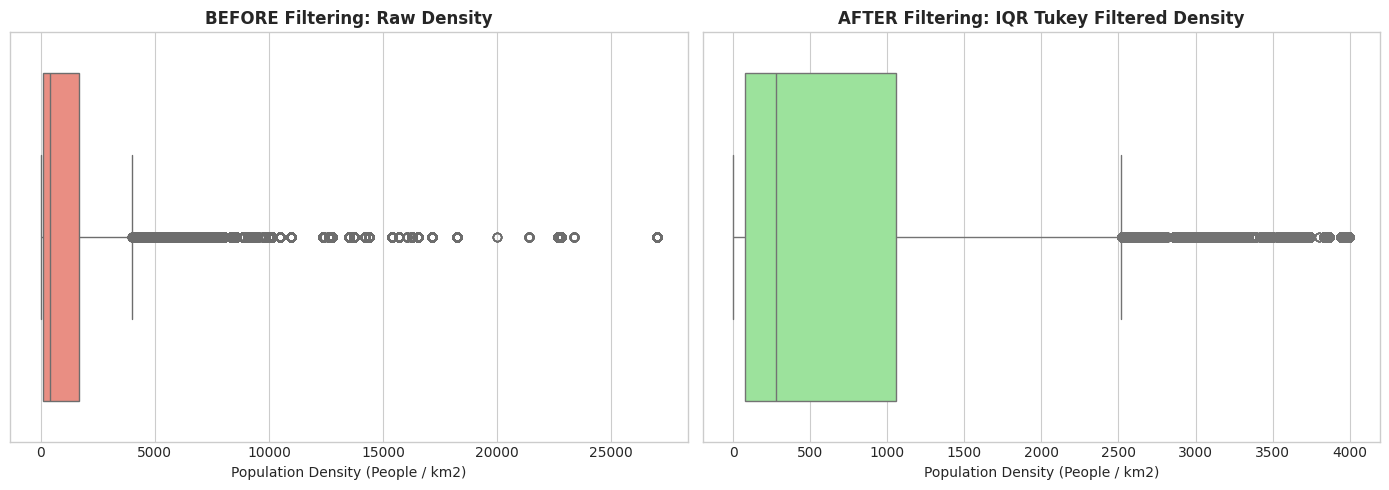

[+] Saved visual outlier comparison artifact to: ../reports/figures/outlier_filtering_comparison.png


In [44]:
target_feature = "Density"

Q1 = df[target_feature].quantile(0.25)
Q3 = df[target_feature].quantile(0.75)
IQR = Q3 - Q1

iqr_lower = Q1 - 1.5 * IQR
iqr_upper = Q3 + 1.5 * IQR

df_iqr_cleaned = df[
    (df[target_feature] >= iqr_lower) &
    (df[target_feature] <= iqr_upper)
]

z_scores = (
    (df[target_feature] - df[target_feature].mean())
    / df[target_feature].std()
)

df_z_cleaned = df[abs(z_scores) <= 3.0]

print(f"=== OUTLIER AUDIT REPORT FOR '{target_feature}' ===")
print(f"Original Record Count: {len(df):,} records")
print(
    f"Tukey IQR Range [{iqr_lower:.2f}, {iqr_upper:.2f}]: "
    f"Excludes {len(df) - len(df_iqr_cleaned):,} records"
)
print(
    f"Z-Score Threshold (|Z| <= 3.0): "
    f"Excludes {len(df) - len(df_z_cleaned):,} records"
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    x=df[target_feature],
    ax=axes[0],
    color="salmon"
)
axes[0].set_title(
    f"BEFORE Filtering: Raw {target_feature}",
    fontsize=12,
    fontweight="bold"
)
axes[0].set_xlabel("Population Density (People / km2)")

sns.boxplot(
    x=df_iqr_cleaned[target_feature],
    ax=axes[1],
    color="lightgreen"
)
axes[1].set_title(
    f"AFTER Filtering: IQR Tukey Filtered {target_feature}",
    fontsize=12,
    fontweight="bold"
)
axes[1].set_xlabel("Population Density (People / km2)")

plt.tight_layout()

fig_filter_path = os.path.join(
    "..",
    "reports",
    "figures",
    "outlier_filtering_comparison.png"
)

plt.savefig(fig_filter_path, dpi=300)
plt.show()

print(
    f"[+] Saved visual outlier comparison artifact to: "
    f"{fig_filter_path}"
)

### Outlier Filtering Interpretation

The population density feature (`Density`) is strongly right-skewed and contains many statistically extreme observations.

Using the non-parametric Tukey IQR method, the valid range is approximately **-2,257 to 4,007 people/km²**, which excludes **77,566 records**. In comparison, the parametric Z-score method excludes only **15,209 records**.

This difference occurs because the Density distribution is highly skewed. Extreme urban-density observations inflate the mean and standard deviation, causing the Z-score threshold to become much less restrictive.

From a business perspective, many high-density observations are valid policyholders living in metropolitan areas rather than data-entry errors. Therefore, these records should not automatically be removed. For statewide insurance risk modeling, retaining the observations and applying a transformation such as `log(1 + Density)` may be preferable to aggressive trimming.